In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
D = pd.read_csv("data/gr24.csv", sep=',', header=None).to_numpy()

print(D)


[[  0 257 187  91 150  80 130 134 243 185 214  70 272 219 293  54 211 290
  268 261 175 250 192 121]
 [257   0 196 228 112 196 167 154 209  86 223 191 180  83  50 219  74 139
   53  43 128  99 228 142]
 [187 196   0 158  96  88  59  63 286 124  49 121 315 172 232  92  81  98
  138 200  76  89 235  99]
 [ 91 228 158   0 120  77 101 105 159 156 185  27 188 149 264  82 182 261
  239 232 146 221 108  84]
 [150 112  96 120   0  63  56  34 190  40 123  83 193  79 148 119 105 144
  123  98  32 105 119  35]
 [ 80 196  88  77  63   0  25  29 216 124 115  47 245 139 232  31 150 176
  207 200  76 189 165  29]
 [130 167  59 101  56  25   0  22 229  95  86  64 258 134 203  43 121 164
  178 171  47 160 178  42]
 [134 154  63 105  34  29  22   0 225  82  90  68 228 112 190  58 108 136
  165 131  30 147 154  36]
 [243 209 286 159 190 216 229 225   0 207 313 173  29 126 248 238 310 389
  367 166 222 349  71 220]
 [185  86 124 156  40 124  95  82 207   0 151 119 159  62 122 147  37 116
   86  90  56  76

In [21]:
import numpy as np

class ACO():
    def __init__(self, strategy='global', alpha=1.0, beta=2.0):
        self.best_road = None
        self.best_dist = float('inf')
        self.alpha = alpha
        self.beta = beta
        
        # Mapeo de estrategias de depósito
        strategies = {
            'global': self._global_deposit,
            'local': self._local_deposit,
            'uniform': self._uniform_deposit
        }
        
        if strategy not in strategies:
            raise ValueError(f"Estrategia '{strategy}' no válida.")
        self._deposit = strategies[strategy]

    def run(self, rho, D, n_ants, max_iters):
        n_cities = D.shape[0]
        # Evitar división por cero en la visibilidad (heurística eta)
        with np.errstate(divide='ignore'):
            eta = 1.0 / D
            eta[np.isinf(eta)] = 0
            
        # Inicialización de feromonas
        tau = np.random.uniform(0.1, 0.5, size=(n_cities, n_cities))

        for t in range(max_iters):
            # Construcción de caminos vectorizada (todas las hormigas a la vez)
            roads = self._build_paths(n_ants, n_cities, tau, eta)
            
            # Cálculo de distancias vectorizado
            distances = self._calculate_distances(roads, D)

            # Actualización de la mejor solución histórica
            min_idx = np.argmin(distances)
            if distances[min_idx] < self.best_dist:
                self.best_dist = distances[min_idx]
                self.best_road = roads[min_idx].copy()

            # Evaporación y depósito
            tau *= (1 - rho)
            self._deposit(roads, distances, tau)

        return self.best_road, self.best_dist

    def _build_paths(self, n_ants, n_cities, tau, eta):
        roads = np.zeros((n_ants, n_cities + 1), dtype=int)
        visited_mask = np.zeros((n_ants, n_cities), dtype=bool)
        
        # Todas inician en la ciudad 0
        current_nodes = np.zeros(n_ants, dtype=int)
        visited_mask[:, 0] = True
        
        # Pre-calculamos la potencia de las feromonas y visibilidad
        # Esto reduce cálculos repetitivos dentro del bucle de pasos
        tau_alpha = np.power(tau, self.alpha)
        eta_beta = np.power(eta, self.beta)
        combined_influence = tau_alpha * eta_beta

        for step in range(1, n_cities):
            # 1. Obtener fila de influencia para los nodos actuales de cada hormiga
            probs = combined_influence[current_nodes, :]
            
            # 2. Aplicar máscara: probabilidad 0 a ciudades ya visitadas
            probs[visited_mask] = 0
            
            # 3. Normalizar probabilidades por fila
            row_sums = probs.sum(axis=1, keepdims=True)
            # Manejo de seguridad para filas con suma cero
            probs = np.divide(probs, row_sums, out=np.zeros_like(probs), where=row_sums != 0)
            
            # 4. Muestreo vectorizado (Ruleta Rusa simultánea)
            cumulative_probs = probs.cumsum(axis=1)
            r = np.random.rand(n_ants, 1)
            next_nodes = (r < cumulative_probs).argmax(axis=1)
            
            # 5. Registrar paso y actualizar estado
            roads[:, step] = next_nodes
            visited_mask[np.arange(n_ants), next_nodes] = True
            current_nodes = next_nodes
            
        # Regreso al origen (ciudad 0)
        roads[:, -1] = 0
        return roads

    def _calculate_distances(self, roads, D):
        # Indexación avanzada para obtener todos los costos de los tramos
        # roads[:, :-1] son los orígenes, roads[:, 1:] son los destinos
        return D[roads[:, :-1], roads[:, 1:]].sum(axis=1)

    def _global_deposit(self, roads, distances, tau):
        # Todas las hormigas dejan feromona: delta = 1 / distancia_total
        delta_tau = 1.0 / distances
        self._atomic_add(tau, roads, delta_tau)

    def _local_deposit(self, roads, distances, tau):
        # Solo la mejor de la iteración actual deposita
        best_idx = np.argmin(distances)
        best_road = roads[best_idx : best_idx + 1]
        delta_tau = np.array([1.0 / distances[best_idx]])
        self._atomic_add(tau, best_road, delta_tau)

    def _uniform_deposit(self, roads, distances, tau, constant=1.0):
        # Todas depositan una cantidad fija
        delta_tau = np.full(roads.shape[0], constant)
        self._atomic_add(tau, roads, delta_tau)

    def _atomic_add(self, tau, roads, delta_tau):
        """Aplica incrementos a la matriz de feromonas de forma atómica."""
        from_nodes = roads[:, :-1].flatten()
        to_nodes = roads[:, 1:].flatten()
        
        # Repetir el valor de delta para cada tramo del camino (n_cities tramos)
        n_steps = roads.shape[1] - 1
        increments = np.repeat(delta_tau, n_steps)
        
        # np.add.at es necesario para manejar colisiones (múltiples hormigas en un arco)
        np.add.at(tau, (from_nodes, to_nodes), increments)
        np.add.at(tau, (to_nodes, from_nodes), increments)

In [22]:
aco = ACO(strategy = 'uniform')
mejor_camino, mejor_distancia = aco.run(rho=0.1, D=D, n_ants=17, max_iters=100)

print(f"Mejor distancia: {mejor_distancia}")
print(f"Mejor camino: {mejor_camino}")

Mejor distancia: 1302
Mejor camino: [ 0 11  3 22  8 12 13 19  1 14 18 17 21 16  9  4  7  6  2 10 20 23  5 15
  0]


# Analisis de hiperparametros
Para esta etapa lo que vamos a hacer es ver el efecto que tiene la tasa de evaporación y la cantidad de feromona depositada sobre los resultados de la busqueda 

In [23]:
import time
rho_s= [0.1, 0.3, 0.5, 0.7, 0.9]

strategies = ['global', 'local', 'uniform']
n_rep = 15

results = {}

for rho in rho_s:
    results[rho]={}
    
    for strategy in strategies:
        aux_dict ={}
        bests_dists = []
        bests_times =[]
        bests_roads = []
        for _ in range(n_rep):
            
            init_time = time.time()
            aco = ACO(strategy = strategy)
            best_road, best_dist = aco.run(rho=rho, D=D, n_ants = 17, max_iters = 200)
            end_time = time.time()

            bests_dists.append(best_dist)
            bests_times.append(end_time - init_time)
            bests_roads.append(best_road)

        results[rho][strategy] = {
            'best_road': bests_roads,
            'best_dist': bests_dists,
            'best_time': bests_times
        }

print(results)

{0.1: {'global': {'best_road': [array([ 0, 15,  5, 23,  7,  2, 10,  6, 20,  4,  9, 16, 21, 17, 18, 14,  1,
       19, 13, 12,  8, 22,  3, 11,  0]), array([ 0, 15,  5,  6,  7, 20,  2, 10, 23,  4,  9, 16, 21, 17, 18, 14,  1,
       19, 13, 12,  8, 22,  3, 11,  0]), array([ 0, 15,  5, 23,  7,  6,  2, 10, 20,  4,  9, 16, 21, 17, 18, 14,  1,
       19, 13, 12,  8, 22,  3, 11,  0]), array([ 0, 15,  5,  6,  7, 20,  2, 10, 23,  4,  9, 16, 21, 17, 18, 14,  1,
       19, 13, 12,  8, 22,  3, 11,  0]), array([ 0, 15,  5, 23,  7,  6,  2, 10, 20,  4,  9, 16, 21, 17, 18, 14,  1,
       19, 13, 12,  8, 22,  3, 11,  0]), array([ 0, 15,  5, 23,  7,  6,  2, 10, 20,  4,  9, 16, 21, 17, 18, 14,  1,
       19, 13, 12,  8, 22,  3, 11,  0]), array([ 0, 15,  5,  6,  7, 20, 10,  2, 23,  4,  9, 16, 21, 17, 18, 14,  1,
       19, 13, 12,  8, 22,  3, 11,  0]), array([ 0, 11,  3, 22,  8, 12, 13, 19,  1, 14, 18, 21, 17,  2, 10,  6,  7,
       20,  4,  9, 16, 23,  5, 15,  0]), array([ 0, 11,  3, 22,  8, 12, 13, 19,  

In [24]:
data_rows = []

for rho in rho_s:
    for strategy in strategies:
        distancias = results[rho][strategy]['best_dist']
        tiempos = results[rho][strategy]['best_time']
        
        # Calcular estadísticas
        data_rows.append({
            'ρ': rho,
            'Estrategia': strategy,
            'Distancia media': np.mean(distancias),
            'Distancia std': np.std(distancias),
            'Tiempo medio (s)': np.mean(tiempos),
            'Tiempo std (s)': np.std(tiempos),
            'Mejor distancia': np.min(distancias),
            'Peor distancia': np.max(distancias)
        })

# Crear DataFrame
df_stats = pd.DataFrame(data_rows)

# Redondear para mejor visualización
df_stats = df_stats.round({
    'Distancia media': 2,
    'Distancia std': 2,
    'Tiempo medio (s)': 4,
    'Tiempo std (s)': 4,
    'Mejor distancia': 2,
    'Peor distancia': 2
})

display(df_stats)

,ρ,Estrategia,Distancia media,Distancia std,Tiempo medio (s),Tiempo std (s),Mejor distancia,Peor distancia
0,0.1,global,1301.27,15.78,0.0534,0.0008,1278,1322
1,0.1,local,1278.33,5.24,0.0512,0.0004,1272,1289
2,0.1,uniform,1303.20,16.96,0.0524,0.0003,1278,1326
3,0.3,global,1311.60,21.21,0.0518,0.0004,1278,1348
4,0.3,local,1328.27,46.36,0.0505,0.0006,1272,1401
5,0.3,uniform,1313.27,20.14,0.0518,0.0003,1278,1339
6,0.5,global,1338.93,28.80,0.0512,0.0003,1298,1397
7,0.5,local,1409.60,65.73,0.0505,0.0005,1302,1533
8,0.5,uniform,1326.60,32.03,0.0522,0.0016,1278,1404
9,0.7,global,1348.93,38.98,0.0540,0.0049,1286,1423


/var/folders/n0/_zbbdy_572bchcg3x3tncg0c0000gn/T/ipykernel_32963/3167954715.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot_dist, x='Estrategia', y='Distancia', ax=axes[0, 0], palette='Set2')
/var/folders/n0/_zbbdy_572bchcg3x3tncg0c0000gn/T/ipykernel_32963/3167954715.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot_dist, x='ρ', y='Distancia', ax=axes[0, 1], palette='Set3')
/var/folders/n0/_zbbdy_572bchcg3x3tncg0c0000gn/T/ipykernel_32963/3167954715.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(d

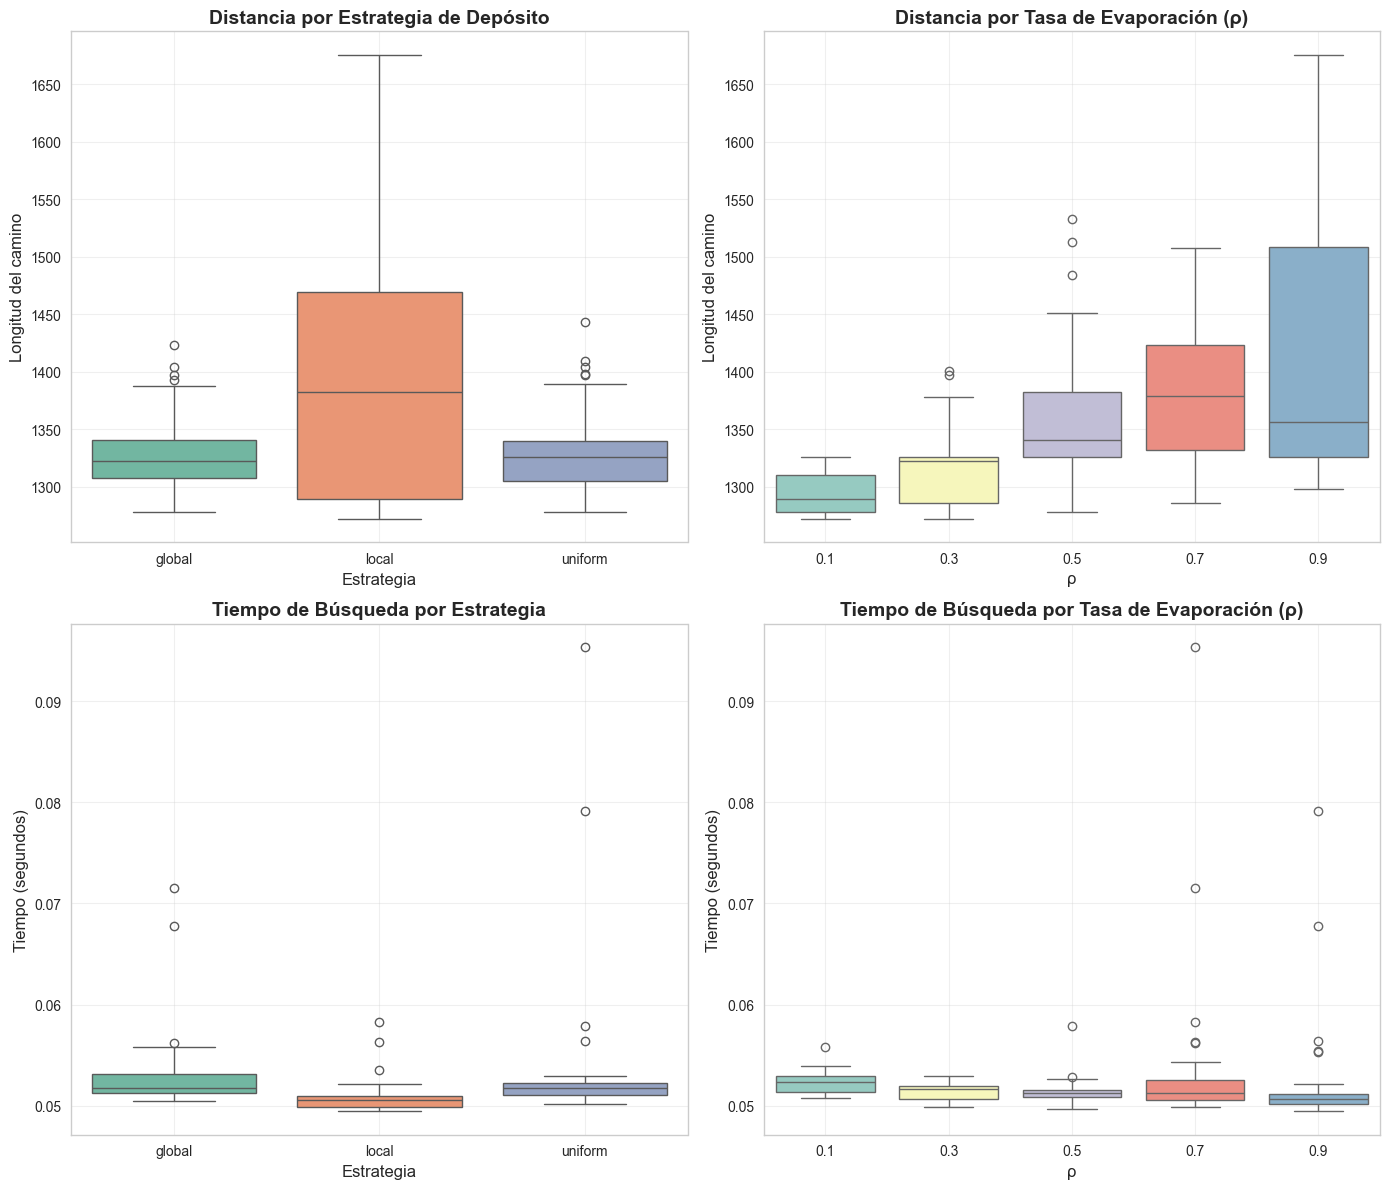

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Primero, preparar los datos para los boxplots de DISTANCIA
data_boxplot_dist = []

for rho in results:
    for strategy in results[rho]:
        distancias = results[rho][strategy]['best_dist']
        for dist in distancias:
            data_boxplot_dist.append({
                'ρ': rho,
                'Estrategia': strategy,
                'Distancia': dist
            })

df_boxplot_dist = pd.DataFrame(data_boxplot_dist)

# Preparar los datos para los boxplots de TIEMPO
data_boxplot_time = []

for rho in results:
    for strategy in results[rho]:
        tiempos = results[rho][strategy]['best_time']
        for t in tiempos:
            data_boxplot_time.append({
                'ρ': rho,
                'Estrategia': strategy,
                'Tiempo': t
            })

df_boxplot_time = pd.DataFrame(data_boxplot_time)

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 12)

# Crear figura con subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gráfico 1: Distancia por Estrategia
sns.boxplot(data=df_boxplot_dist, x='Estrategia', y='Distancia', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distancia por Estrategia de Depósito', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Estrategia', fontsize=12)
axes[0, 0].set_ylabel('Longitud del camino', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Distancia por ρ
sns.boxplot(data=df_boxplot_dist, x='ρ', y='Distancia', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Distancia por Tasa de Evaporación (ρ)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('ρ', fontsize=12)
axes[0, 1].set_ylabel('Longitud del camino', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tiempo por Estrategia
sns.boxplot(data=df_boxplot_time, x='Estrategia', y='Tiempo', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Tiempo de Búsqueda por Estrategia', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Estrategia', fontsize=12)
axes[1, 0].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Tiempo por ρ
sns.boxplot(data=df_boxplot_time, x='ρ', y='Tiempo', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Tiempo de Búsqueda por Tasa de Evaporación (ρ)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('ρ', fontsize=12)
axes[1, 1].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Optimización sobre cantidad de hormigas

Fijamos los mejores hiperparámetros encontrados (ρ=0.1, estrategia=global) y barremos distintas cantidades de hormigas para identificar cuál produce el menor costo.

In [26]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 80
N_REP    = 10   # repeticiones por trial

def objective(trial):
    n_ants   = trial.suggest_int('n_ants',   5,   100)
    rho      = trial.suggest_float('rho',    0.05, 0.95, step=0.05)
    alpha    = trial.suggest_float('alpha',  0.5,  3.0,  step=0.5)
    beta     = trial.suggest_float('beta',   1.0,  5.0,  step=0.5)
    strategy = trial.suggest_categorical('strategy', ['global', 'local', 'uniform'])

    dists = []
    for _ in range(N_REP):
        aco = ACO(strategy=strategy, alpha=alpha, beta=beta)
        _, dist = aco.run(rho=rho, D=D, n_ants=n_ants, max_iters=200)
        dists.append(dist)

    return np.min(dists)   # mejor absoluto del trial

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
best_val = study.best_value

print(f"\n{'='*50}")
print(f"Mejor distancia absoluta encontrada : {best_val:.0f}")
print(f"Hiperparámetros óptimos:")
for k, v in best.items():
    print(f"  {k:12s} = {v}")

Best trial: 13. Best value: 1272: 100%|██████████| 80/80 [01:06<00:00,  1.19it/s]


Mejor distancia absoluta encontrada : 1272
Hiperparámetros óptimos:
  n_ants       = 61
  rho          = 0.25
  alpha        = 0.5
  beta         = 4.5
  strategy     = global


<Figure size 700x400 with 0 Axes>

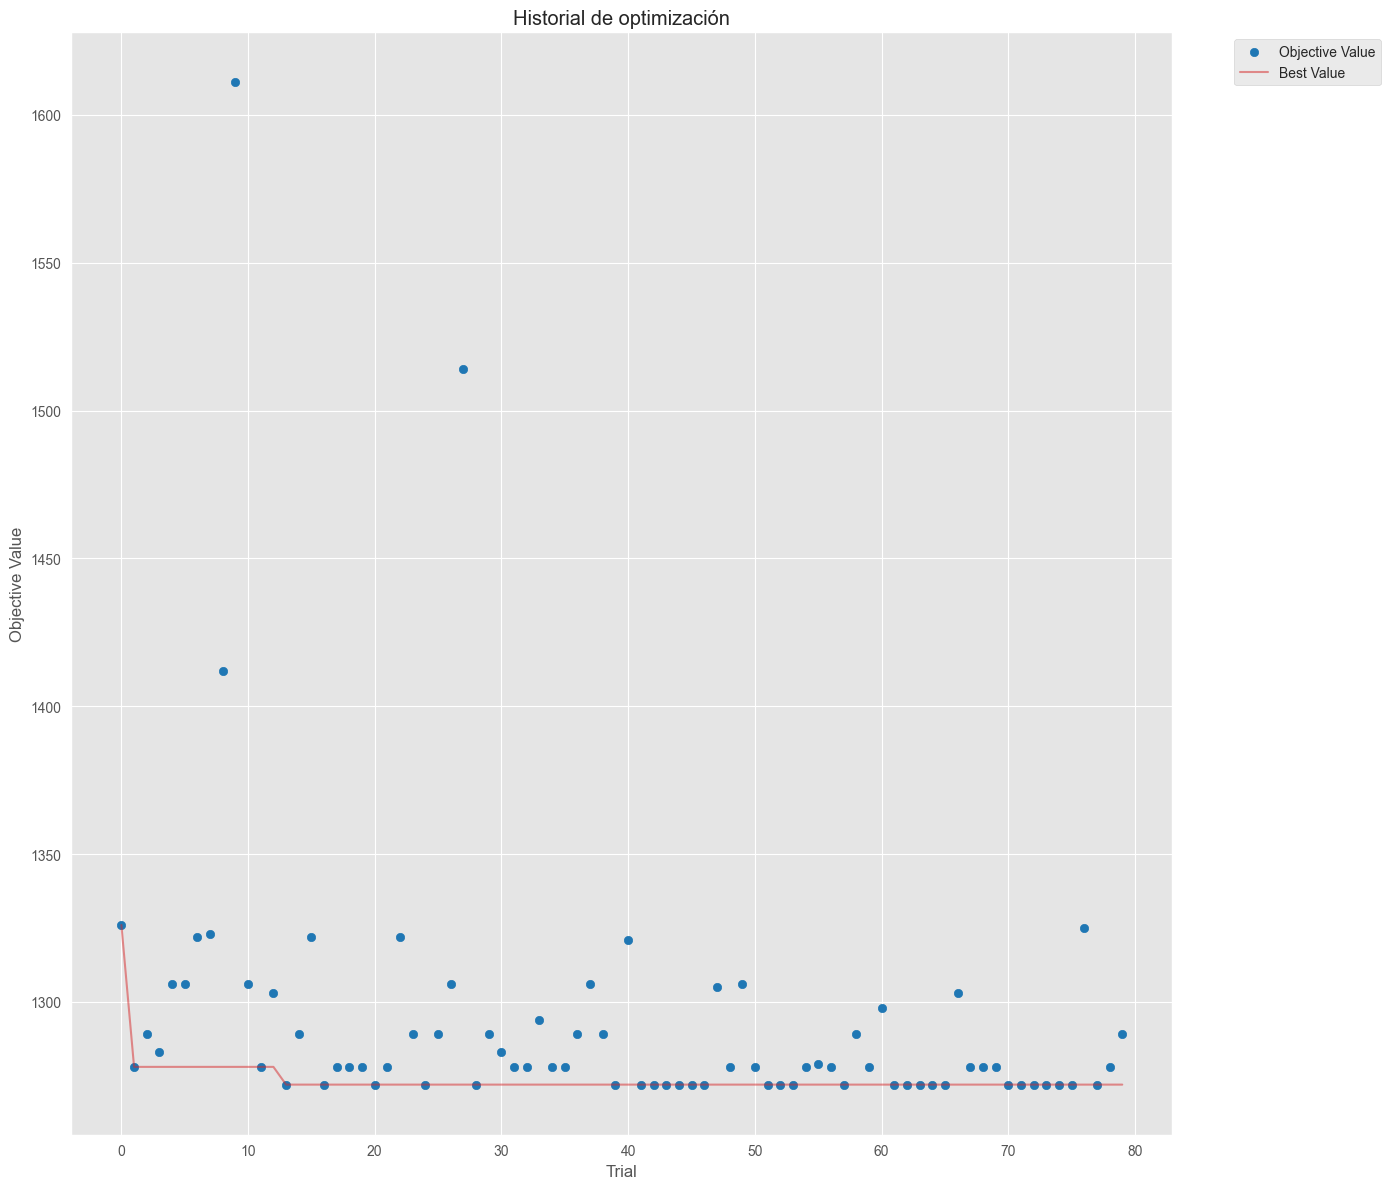

<Figure size 700x400 with 0 Axes>

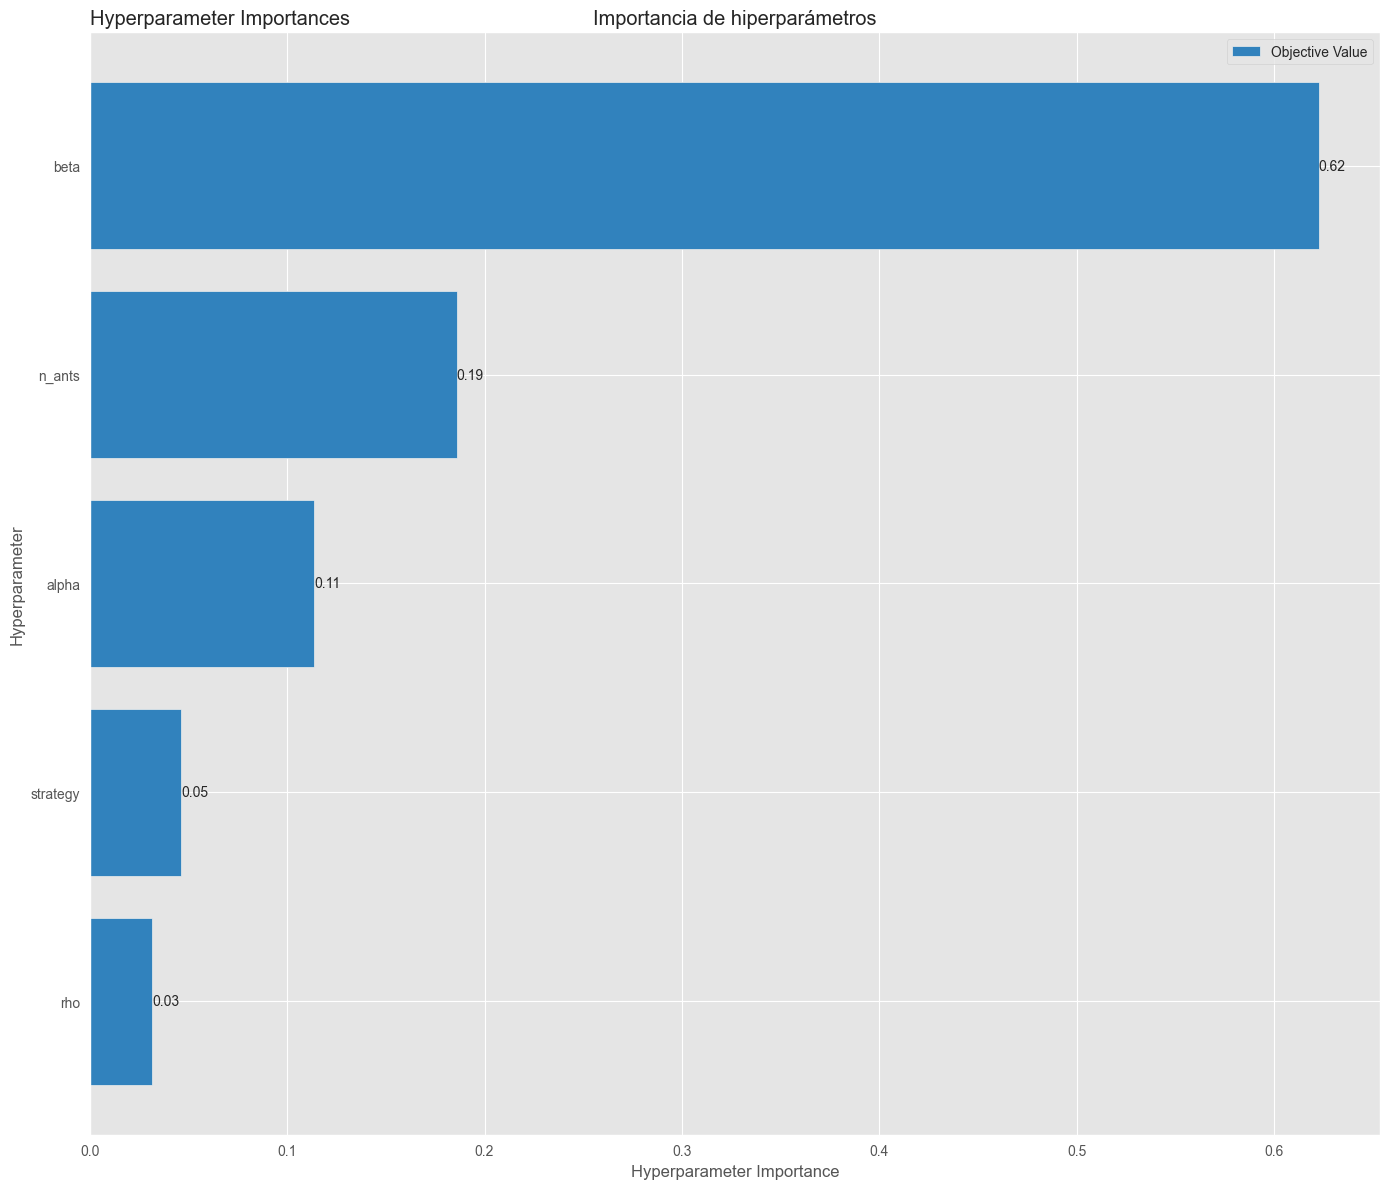


Verificación con los mejores parámetros (30 corridas):
  Mejor    : 1278
  Media    : 1286.07
  Std      : 9.73


In [27]:
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)
import warnings
warnings.filterwarnings('ignore', category=optuna.exceptions.ExperimentalWarning)

plt.figure(figsize=(7, 4))
plot_optimization_history(study)
plt.title('Historial de optimización')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plot_param_importances(study)
plt.title('Importancia de hiperparámetros')
plt.tight_layout()
plt.show()

# Verificación final: 30 corridas con los mejores parámetros
print("\nVerificación con los mejores parámetros (30 corridas):")
final_dists = []
for _ in range(30):
    aco = ACO(strategy=best['strategy'], alpha=best['alpha'], beta=best['beta'])
    _, dist = aco.run(rho=best['rho'], D=D, n_ants=best['n_ants'], max_iters=200)
    final_dists.append(dist)

print(f"  Mejor    : {np.min(final_dists)}")
print(f"  Media    : {np.mean(final_dists):.2f}")
print(f"  Std      : {np.std(final_dists):.2f}")